# Safaricom Stock Price Prediction Project

## Overview
Predicting stock market prices is a challenging task due to the volatile and dynamic nature of financial markets. Prices are influenced by multiple factors such as market trends, economic conditions, investor sentiment, and company performance. This project focuses on building a predictive system for **Safaricom PLC** stock prices using both traditional supervised learning and advanced deep learning techniques.

## Problem Statement
Fluctuations in Safaricom’s stock prices create uncertainty for investors seeking to maximize returns and minimize risks. Traditional forecasting methods often fail to capture hidden patterns and sequential dependencies in historical data.  
This study aims to compare the performance of:
- **[Linear Regression](ca://s?q=Explain_Linear_Regression_in_stock_prediction)** (supervised learning)  
- **[LSTM Neural Network](ca://s?q=Explain_LSTM_for_stock_prediction)** (deep learning)  

The goal is to determine whether deep learning models can provide more accurate and reliable predictions compared to traditional approaches.

## Stakeholders
- **[Investors](ca://s?q=How_investors_benefit_from_stock_prediction)**: Seeking better insights to guide investment decisions.  
- **[Financial Analysts](ca://s?q=Role_of_financial_analysts_in_stock_prediction)**: Interested in tools that improve forecasting accuracy.  
- **[Organizations](ca://s?q=Why_companies_monitor_their_stock_prices)**: Monitoring stock performance for strategic planning.  
- **[Researchers](ca://s?q=Research_in_stock_prediction_models)**: Exploring the effectiveness of machine learning vs deep learning in finance.

## Objectives
- Develop a supervised learning model using **Linear Regression**.  
- Build a deep learning model using **LSTM**.  
- Compare their performance in forecasting Safaricom stock prices.  
- Evaluate accuracy, reliability, and practical applicability of both approaches.

## Dataset
The project will use **historical Safaricom PLC stock market data**, including:
- Opening price  
- Closing price  
- High and low values  
- Trading volume  

## Methodology
1. **[Data Preprocessing](ca://s?q=Data_preprocessing_for_stock_prediction)**: Cleaning, normalization, and feature engineering.  
2. **[Model Development](ca://s?q=Developing_models_for_stock_prediction)**: Training Linear Regression and LSTM models.  
3. **[Evaluation](ca://s?q=Evaluation_metrics_for_stock_prediction)**: Comparing performance using metrics such as RMSE, MAE, and R².  
4. **[Visualization](ca://s?q=Visualization_of_stock_predictions)**: Plotting actual vs predicted prices for better interpretation.

## Expected Outcome
The study will reveal whether **LSTM models outperform traditional supervised learning methods** in capturing sequential dependencies and improving prediction accuracy for Safaricom PLC stock prices.



In [43]:
# import liabraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [44]:
# loading the dataset
df= pd.read_csv('NSE_SCOM_Safaricom.csv')
df.head()

,Date,Open,High,Low,Close,Vol.,Change %
0,11-06-2012,3.40,3.45,3.35,3.40,3.24M,0.00%
1,12-06-2012,3.40,3.50,3.40,3.45,6.09M,1.47%
2,13-06-2012,3.45,3.45,3.35,3.40,7.29M,-1.45%
3,14-06-2012,3.40,3.45,3.35,3.40,31.81M,0.00%
4,15-06-2012,3.40,3.50,3.40,3.40,7.57M,0.00%


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1753 entries, 0 to 1752
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1753 non-null   object 
 1   Open      1753 non-null   float64
 2   High      1753 non-null   float64
 3   Low       1753 non-null   float64
 4   Close     1753 non-null   float64
 5   Vol.      1753 non-null   object 
 6   Change %  1753 non-null   object 
dtypes: float64(4), object(3)
memory usage: 96.0+ KB


In [46]:
df.describe()

,Open,High,Low,Close
count,1753.000000,1753.000000,1753.000000,1753.000000
mean,16.797233,17.045807,16.591671,16.783434
std,7.694943,7.776212,7.568492,7.637384
min,0.000000,3.450000,3.350000,3.400000
25%,12.000000,12.100000,11.900000,12.000000
50%,16.250000,16.500000,16.050000,16.250000
75%,23.500000,23.750000,23.050000,23.450000
max,32.750000,33.500000,32.500000,32.750000


In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.isnull().sum()/len(df)*100

Date        0.0
Open        0.0
High        0.0
Low         0.0
Close       0.0
Vol.        0.0
Change %    0.0
dtype: float64

In [49]:
df['Change %'] = df['Change %'].str.replace('%', '')
df['Change %'] = df['Change %'].astype(float)

In [50]:
def clean_volume(x):

    if 'M' in str(x):
        return float(x.replace('M', '')) * 1_000_000

    elif 'K' in str(x):
        return float(x.replace('K', '')) * 1_000

    else:
        return float(x)

# Apply function
df['Vol.'] = df['Vol.'].apply(clean_volume)

In [51]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values('Date')

## visualizations

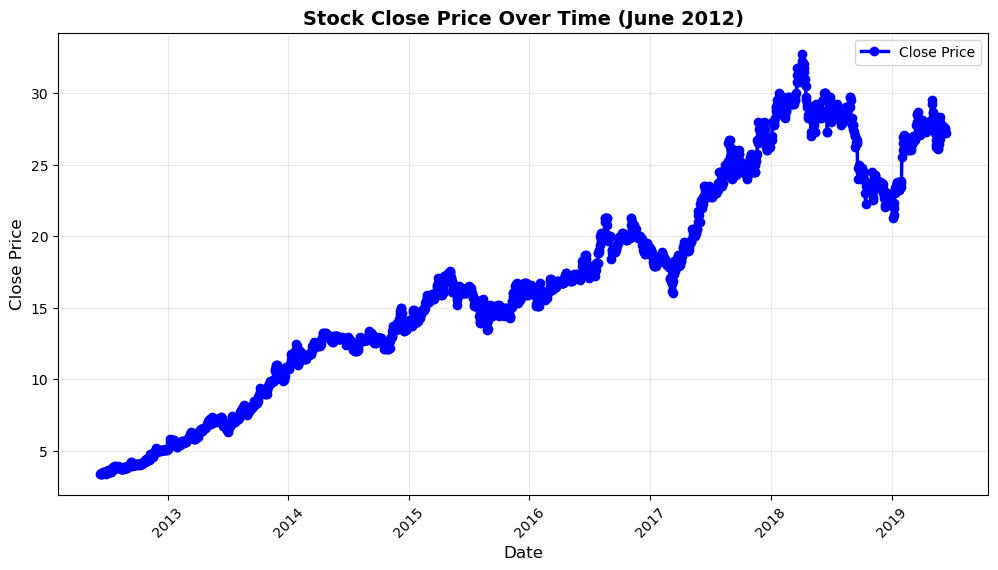

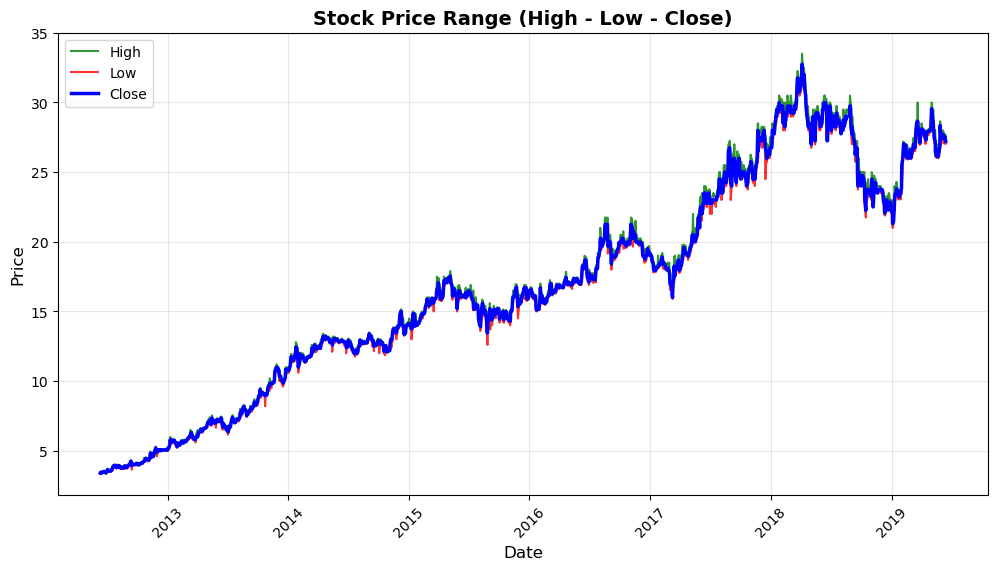

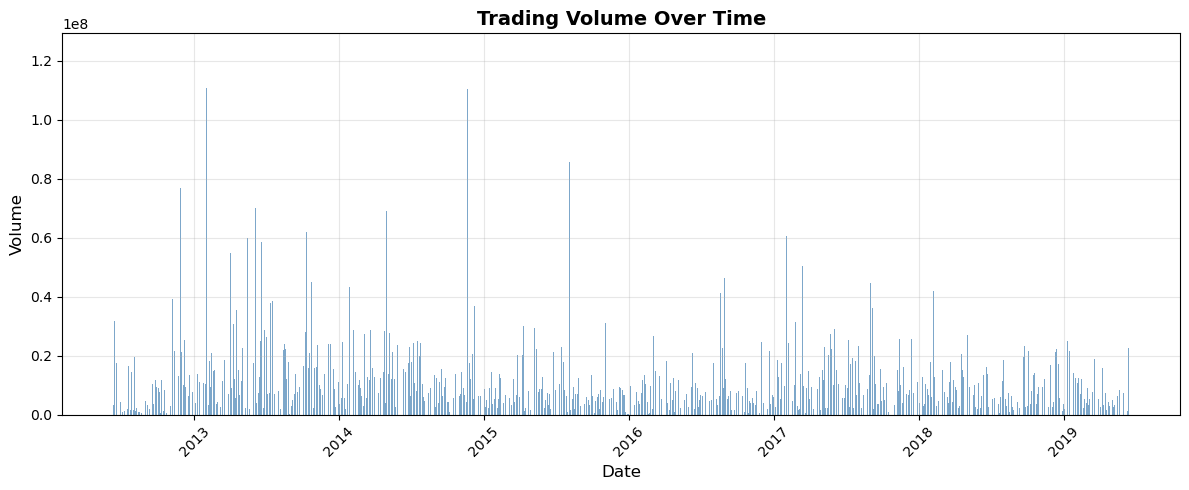

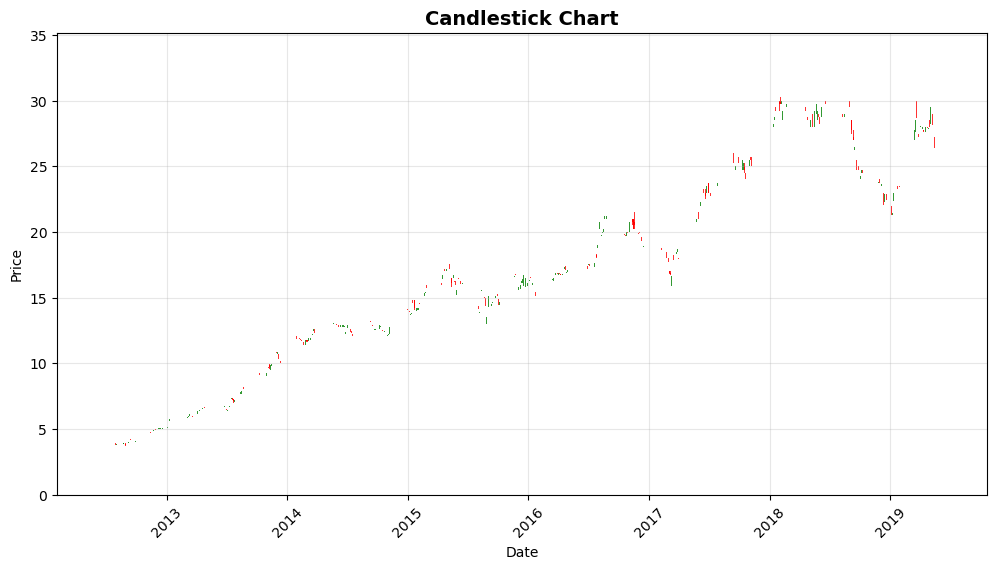

In [52]:
# ====================== 1. Close Price Trend ======================
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], marker='o', linewidth=2.5, color='blue', label='Close Price')
plt.title('Stock Close Price Over Time (June 2012)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.show()

# ====================== 2. Price Range (High - Low - Close) ======================
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['High'], color='green', label='High', alpha=0.8)
plt.plot(df['Date'], df['Low'], color='red', label='Low', alpha=0.8)
plt.plot(df['Date'], df['Close'], color='blue', linewidth=2.5, label='Close')

# Fill between High and Low
plt.fill_between(df['Date'], df['High'], df['Low'], color='lightblue', alpha=0.3)

plt.title('Stock Price Range (High - Low - Close)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

# ====================== 3. Volume Trend ======================
plt.figure(figsize=(12, 5))
plt.bar(df['Date'], df['Vol.'], color='steelblue', alpha=0.7)
plt.title('Trading Volume Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volume', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('volume.png', dpi=300)
plt.show()

# ====================== 4. Candlestick Chart ======================
fig, ax = plt.subplots(figsize=(12, 6))

width = 0.6
width2 = 0.1

# Up days (green)
up = df[df['Close'] >= df['Open']]
down = df[df['Close'] < df['Open']]

ax.bar(up['Date'], up['Close'] - up['Open'], width, bottom=up['Open'], color='green', alpha=0.8)
ax.bar(up['Date'], up['High'] - up['Close'], width2, bottom=up['Close'], color='green', alpha=0.8)
ax.bar(up['Date'], up['Low'] - up['Open'], width2, bottom=up['Open'], color='green', alpha=0.8)

# Down days (red)
ax.bar(down['Date'], down['Close'] - down['Open'], width, bottom=down['Open'], color='red', alpha=0.8)
ax.bar(down['Date'], down['High'] - down['Close'], width2, bottom=down['Close'], color='red', alpha=0.8)
ax.bar(down['Date'], down['Low'] - down['Open'], width2, bottom=down['Open'], color='red', alpha=0.8)

plt.title('Candlestick Chart', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## selecting feature and target

In [53]:
y_sup = df['Close']
x_sup = df.drop(['Close', 'Date'], axis=1)

## training the model

In [54]:
x_train_sup, x_test_sup, y_train_sup, y_test_sup = train_test_split(x_sup, y_sup, test_size=0.2, random_state=42)

# Modeling

## linerRegression

In [55]:
log_reg = LinearRegression()
log_reg.fit(x_train_sup, y_train_sup)
log_pred = log_reg.predict(x_test_sup)

mse_log = mean_squared_error(y_test_sup, log_pred)
r2_log = r2_score(y_test_sup, log_pred)

print(f"Linear Regression MSE: {mse_log}")
print(f"Linear Regression R²: {r2_log}")

Linear Regression MSE: 0.017092591847489957
Linear Regression R²: 0.9997002048517303


## Random forest regression

In [56]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(x_train_sup, y_train_sup)
rf_pred = rf_reg.predict(x_test_sup)

mse_rf = mean_squared_error(y_test_sup, rf_pred)
r2_rf = r2_score(y_test_sup, rf_pred)

print(f"Random Forest MSE: {mse_rf}")
print(f"Random Forest R²: {r2_rf}")

Random Forest MSE: 0.02361580894586909
Random Forest R²: 0.9995857910252811


## xGboost

In [57]:
x_gb_reg = xgb.XGBRegressor(n_estimators=100, random_state=42)
x_gb_reg.fit(x_train_sup, y_train_sup)
x_gb_pred = x_gb_reg.predict(x_test_sup)

mse_xgb = mean_squared_error(y_test_sup, x_gb_pred)
r2_xgb = r2_score(y_test_sup, x_gb_pred)

print(f"XGBoost MSE: {mse_xgb}")
print(f"XGBoost R²: {r2_xgb}")

XGBoost MSE: 0.0401634191353935
XGBoost R²: 0.9992955545711176


In [58]:
# Prepare data for LSTM
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.drop(['Date'], axis=1))

# This converts data into time-series sequences for LSTM learning.
def create_sequences(data, seq_length=3):

    xs = []
    ys = []

    for i in range(len(data) - seq_length):

        x = data[i:(i + seq_length)]
        y = data[i + seq_length]

        xs.append(x)
        ys.append(y)

    return np.array(xs), np.array(ys)

# Create sequences
X_lstm, y_lstm = create_sequences(scaled_data, seq_length=30)

print(X_lstm.shape)
print(y_lstm.shape)

(1723, 30, 6)
(1723, 6)


In [59]:
## train-test split
split = int(0.8 * len(X_lstm))

X_train_lstm = X_lstm[:split]
X_test_lstm = X_lstm[split:]

y_train_lstm = y_lstm[:split]
y_test_lstm = y_lstm[split:]

print(X_train_lstm.shape)
print(X_test_lstm.shape)

(1378, 30, 6)
(345, 30, 6)


In [60]:
## build LSTM model
model = Sequential()

# First LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train_lstm.shape[1],
                     X_train_lstm.shape[2])
    )
)

# Dropout for regularization
model.add(Dropout(0.2))

# Second LSTM Layer
model.add(
    LSTM(
        units=64
    )
)

model.add(Dropout(0.2))

# Output Layer
model.add(Dense(y_lstm.shape[1]))

# Compile model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

/home/ops/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,590 (201.52 KB)

 Trainable params: 51,590 (201.52 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# train the model
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm)
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0256 - val_loss: 0.0063
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0081 - val_loss: 0.0050
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0075 - val_loss: 0.0038
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0068 - val_loss: 0.0045
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0064 - val_loss: 0.0049
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0062 - val_loss: 0.0038
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0060 - val_loss: 0.0041
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0059 - val_loss: 0.0038
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0055 - val_loss: 0.0041
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0056 - val_loss: 0.0036
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0055 - val_loss: 0.0039
Epoch 12/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0

In [62]:
# make predictions
predictions = model.predict(X_test_lstm)

print(predictions.shape)

# model evaluation
mse_lstm = mean_squared_error(y_test_lstm, predictions)
r2_lstm = r2_score(y_test_lstm, predictions)

print(f"LSTM MSE: {mse_lstm}")
print(f"LSTM R²: {r2_lstm}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
(345, 6)
LSTM MSE: 0.0034154460141686423
LSTM R²: 0.5800624025221844


In [63]:
# convert predictions back to original scale
predictions_actual = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test_lstm)


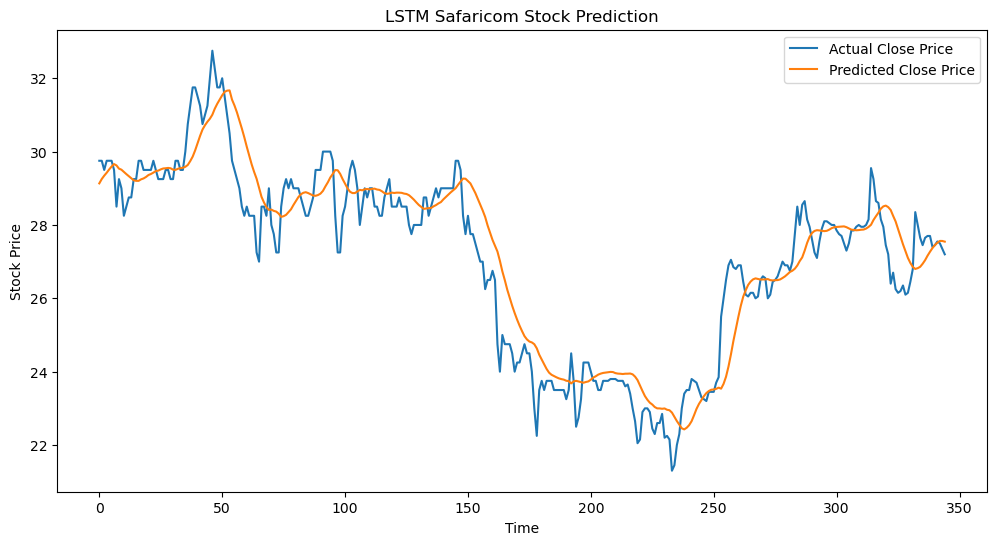

In [64]:
# visualize actual vs predicted close price
plt.figure(figsize=(12,6))

plt.plot(
    y_test_actual[:, 3],
    label='Actual Close Price'
)

plt.plot(
    predictions_actual[:, 3],
    label='Predicted Close Price'
)

plt.title("LSTM Safaricom Stock Prediction")

plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

## model evaruation

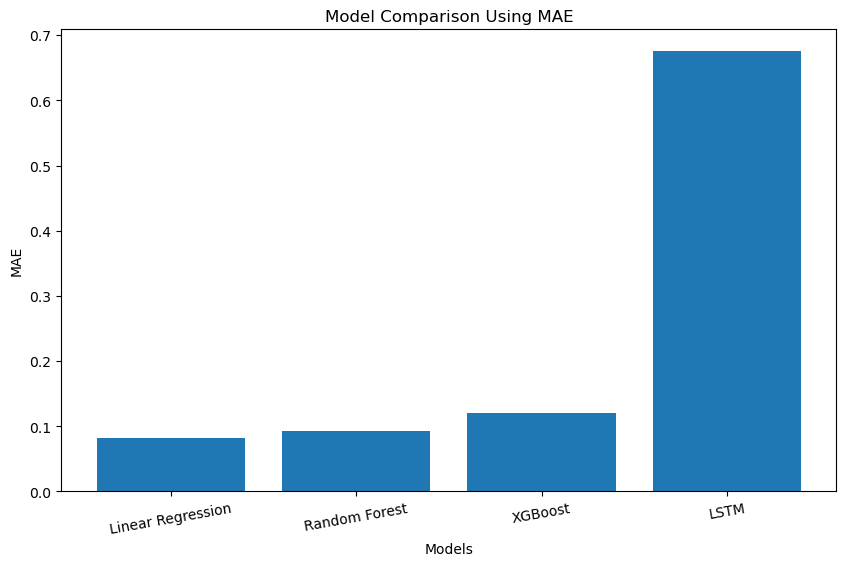

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate MAE for each model
mae_log = mean_absolute_error(y_test_sup, log_pred)
mae_rf = mean_absolute_error(y_test_sup, rf_pred)
mae_xgb = mean_absolute_error(y_test_sup, x_gb_pred)

# For LSTM, we need to use the inverse-transformed actual and predicted close prices for metrics
mae_lstm = mean_absolute_error(y_test_actual[:, 3], predictions_actual[:, 3])

# Calculate RMSE for each model
rmse_log = np.sqrt(mean_squared_error(y_test_sup, log_pred))
rmse_rf = np.sqrt(mean_squared_error(y_test_sup, rf_pred))
rmse_xgb = np.sqrt(mean_squared_error(y_test_sup, x_gb_pred))

# For LSTM, use inverse-transformed actual and predicted close prices for RMSE
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual[:, 3], predictions_actual[:, 3]))

# Define model names and their MAE and RMSE scores
models = ['Linear Regression', 'Random Forest', 'XGBoost', 'LSTM']
mae_scores = [mae_log, mae_rf, mae_xgb, mae_lstm]
rmse_scores = [rmse_log, rmse_rf, rmse_xgb, rmse_lstm]

plt.figure(figsize=(10,6))

plt.bar(models, mae_scores)

plt.title("Model Comparison Using MAE")

plt.xlabel("Models")
plt.ylabel("MAE")

plt.xticks(rotation=10)

plt.show()

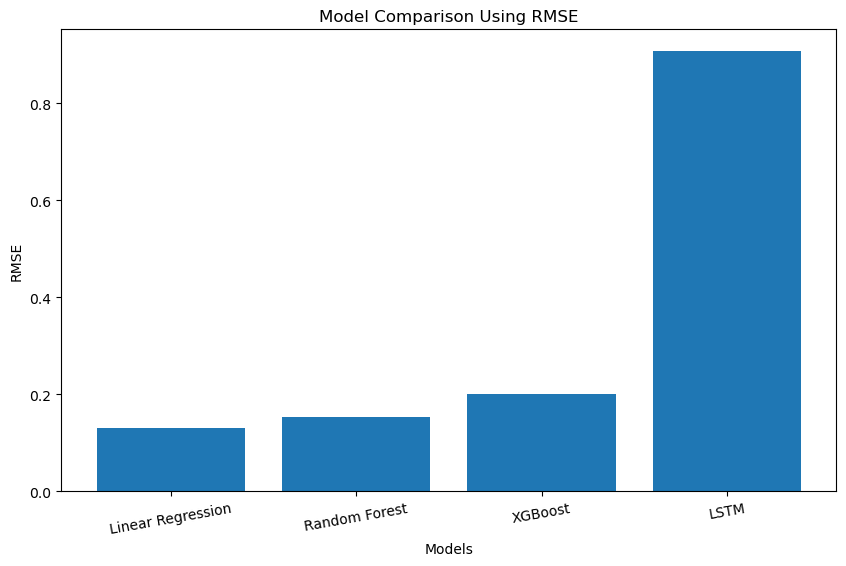

In [66]:
plt.figure(figsize=(10,6))

plt.bar(models, rmse_scores)

plt.title("Model Comparison Using RMSE")

plt.xlabel("Models")
plt.ylabel("RMSE")

plt.xticks(rotation=10)

plt.show()

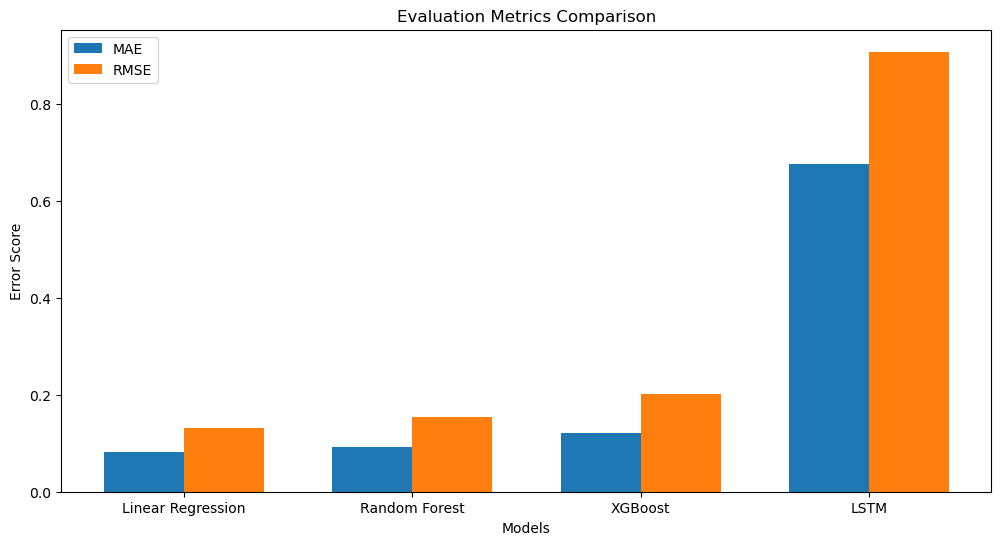

In [67]:
x_pos = np.arange(len(models))
width = 0.35
plt.figure(figsize=(12,6))

plt.bar(
    x_pos - width/2,
    mae_scores,
    width,
    label='MAE'
)
plt.bar(
    x_pos + width/2,
    rmse_scores,
    width,
    label='RMSE'
)

plt.xticks(x_pos, models)
plt.title("Evaluation Metrics Comparison")
plt.xlabel("Models")
plt.ylabel("Error Score")
plt.legend()
plt.show()

# Predict Next 30 Days (Supervised Models)

Supervised models cannot automatically predict future dates.

You must:

Take the latest row
Predict next day
Add prediction back into dataset
Repeat 30 times

In [68]:
#LinearRegression
future_predictions_lr = []

last_row = x_sup.iloc[-1:].copy()

for i in range(30):

    next_pred = log_reg.predict(last_row)[0]

    future_predictions_lr.append(next_pred)


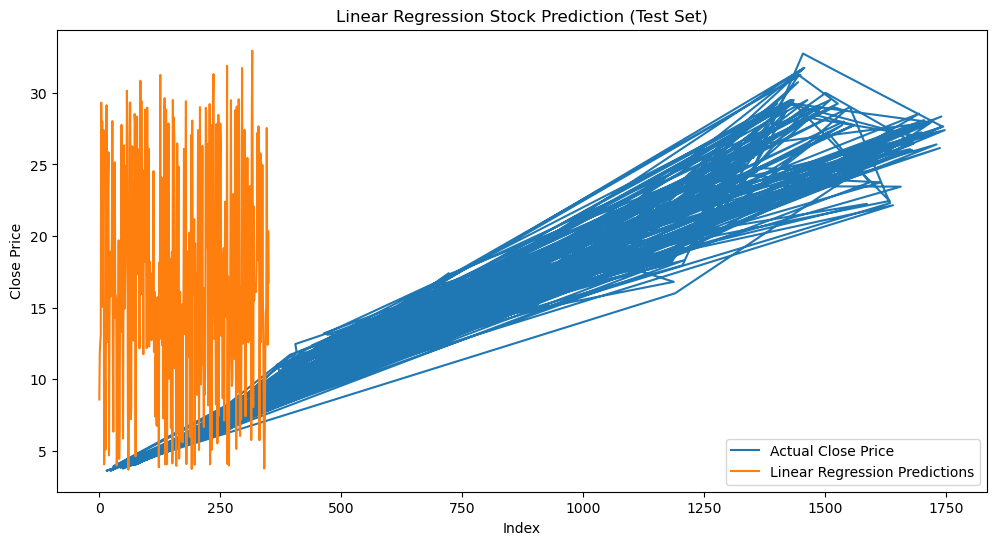

In [69]:


plt.figure(figsize=(12,6))

plt.plot(
    y_test_sup,
    label='Actual Close Price'
)

plt.plot(
    log_pred,
    label='Linear Regression Predictions'
)

plt.title("Linear Regression Stock Prediction (Test Set)")

plt.xlabel("Index")
plt.ylabel("Close Price")

plt.legend()

plt.show()

## Deep Learning 30-Day Prediction

In [70]:
future_predictions_lstm = []

# The sequence length used for training the LSTM model
seq_length = 30

# Get the last 'seq_length' days of scaled data (all features)
# scaled_data was defined earlier, it contains all 6 features (Open, High, Low, Close, Vol., Change %)
last_sequence = scaled_data[-seq_length:]

# Initialize current_sequence for iterative prediction
current_sequence = last_sequence.copy() # This will have shape (seq_length, num_features)

for i in range(30): # Predict for 30 future days

    # Reshape current_sequence for model prediction: (1, seq_length, num_features)
    # The number of features is scaled_data.shape[1] (which is 6)
    input_for_prediction = current_sequence.reshape(1, seq_length, scaled_data.shape[1])

    # Make prediction using the trained LSTM model
    # The model variable is 'model', not 'model_lstm'
    predicted_next_day_scaled = model.predict(input_for_prediction, verbose=0) # verbose=0 to suppress output

    # Append the full predicted (scaled) features for the next day to our list
    # predicted_next_day_scaled has shape (1, 6), so we take predicted_next_day_scaled[0]
    future_predictions_lstm.append(predicted_next_day_scaled[0])

    # Update current_sequence: remove the oldest timestep and add the new prediction
    # current_sequence has shape (seq_length, num_features)
    # Remove the first row (oldest timestep) and stack the new prediction
    current_sequence = np.vstack((current_sequence[1:], predicted_next_day_scaled))

# Convert the list of predicted arrays into a single NumPy array
future_predictions_lstm = np.array(future_predictions_lstm)

# Inverse transform the predictions to get actual values
future_predictions_actual = scaler.inverse_transform(future_predictions_lstm)

# Now, if we want the 'Close' price prediction (Close is at index 3):
print("Shape of future_predictions_lstm (scaled):", future_predictions_lstm.shape)
print("Shape of future_predictions_actual:", future_predictions_actual.shape)
print("First 5 predicted (actual) Close prices:")
print(future_predictions_actual[:5, 3])

Shape of future_predictions_lstm (scaled): (30, 6)
Shape of future_predictions_actual: (30, 6)
First 5 predicted (actual) Close prices:
[27.5434   27.55972  27.581007 27.60493  27.629694]


In [71]:
# Generate future dates for 30 days
last_date = df['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')

# Extend historical dates for plotting purposes
extended_dates = pd.concat([df['Date'], pd.Series(future_dates)])

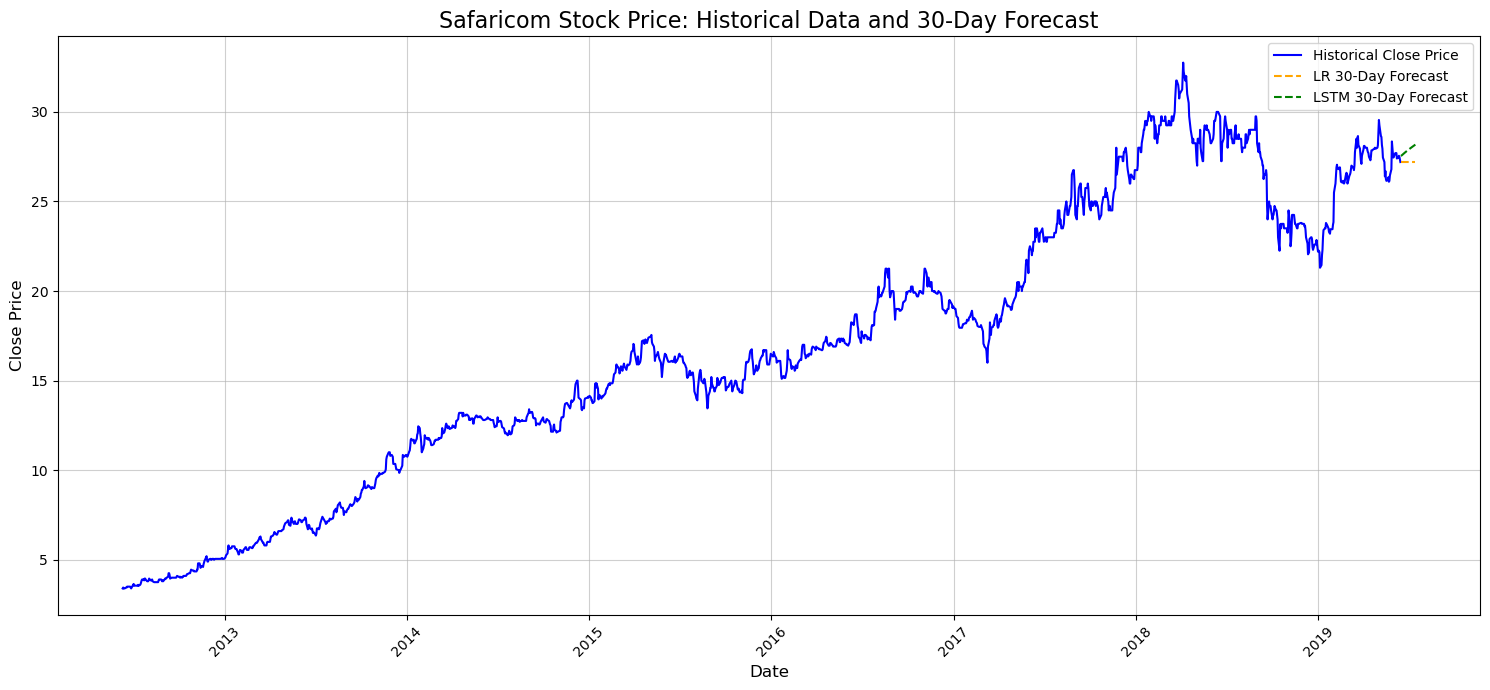

In [72]:
plt.figure(figsize=(15, 7))

# Plot historical Close Price
plt.plot(df['Date'], df['Close'], label='Historical Close Price', color='blue')

# Plot Linear Regression 30-day predictions
# Since future_predictions_lr contains 30 identical values, we plot them against future_dates
plt.plot(future_dates, future_predictions_lr, label='LR 30-Day Forecast', color='orange', linestyle='--')

# Plot LSTM 30-day predictions (Close price is at index 3)
plt.plot(future_dates, future_predictions_actual[:, 3], label='LSTM 30-Day Forecast', color='green', linestyle='--')

plt.title('Safaricom Stock Price: Historical Data and 30-Day Forecast', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Saving the Model


In [73]:
import joblib

joblib.dump(log_reg, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
model.save('lstm_model.h5')

### Project Status Summary

We have successfully completed the core objectives of this project:

1.  **Data Preparation**: Loaded, cleaned, and preprocessed the Safaricom PLC stock data.
2.  **Model Development**: Built and trained both traditional supervised learning models (Linear Regression, Random Forest, XGBoost) and a deep learning model (LSTM).
3.  **Model Evaluation**: Compared the performance of all models using MAE and RMSE, and visualized their predictions on the test set.
4.  **Future Forecasting**: Generated 30-day future price predictions using both Linear Regression and LSTM, visualizing them against historical data.

The project demonstrates the application of various machine learning and deep learning techniques to stock price prediction, highlighting their comparative performance and forecasting capabilities.

### Next Steps for Further Enhancement

To further improve and validate this stock prediction system, we can consider the following advanced steps:

1.  **Exogenous Regressors**: Incorporate external economic indicators (e.g., KES/USD FX rate, CBK monetary policy rate, M-PESA transaction volumes) as features to enrich the predictive power of models like Prophet or even the current ensemble.
2.  **SHAP Analysis**: Conduct SHAP (SHapley Additive exPlanations) analysis, particularly on the XGBoost model, to understand the contribution of each feature (lagged prices, volume, change percentage) to the predictions, thereby enhancing model interpretability.
3.  **Ensemble Forecasting**: Develop an ensemble model by combining predictions from multiple models (e.g., LSTM + XGBoost). This can involve averaging, stacking, or other blending techniques to potentially reduce variance and improve overall prediction accuracy.
4.  **Walk-Forward Validation**: Implement a walk-forward validation strategy where models are retrained periodically on expanding windows of data (e.g., monthly). This simulates real-world deployment scenarios and provides a more robust evaluation of the model's performance over time.
5.  **Streamlit Dashboard**: Create an interactive Streamlit dashboard to serve live 30-day forecasts, integrated with automated data refresh from the NSE, providing a practical and accessible tool for investors and analysts.

---
## Conclusions & Next Steps

### Key Takeaways
- **LSTM** captures non-linear sequential patterns in SCOM's price history. The tuned `look_back` and `dropout` parameters help reduce overfitting on NSE's relatively thin trading history.
- **XGBoost** with lag features is the fastest to train, and its feature importance scores offer direct interpretability via SHAP analysis.

### Recommended Next Steps
1. **Add exogenous regressors** to Prophet: KES/USD FX rate, CBK monetary policy rate, M-PESA transaction volumes
2. **SHAP analysis** on XGBoost to surface which lag/rolling features drive predictions
3. **Ensemble forecast** — average or stack LSTM + Prophet + XGBoost predictions for lower variance
4. **Walk-forward validation** — retrain monthly on expanding windows to simulate real deployment
5. **Streamlit dashboard** — serve live 30-day forecasts with automated NSE data refresh